In [1]:
from dask.distributed import Client

client = Client("tcp://127.0.0.1:42925")
client

<Client: 'tcp://127.0.0.1:42925' processes=6 threads=48, memory=48.00 GiB>

In [2]:
import numpy as np
import xarray as xr
import pandas as pd
from xhistogram.xarray import histogram as xhist
from xgcm.grid import Grid
import gsw

import rioxarray
import seaborn as sns
import xrft

import glob

import gcm_filters

import os.path as op

from scipy.interpolate import griddata, interpn

import warnings
warnings.filterwarnings("ignore")

# from xeofs.models import EOF
from pydmd import DMD, BOPDMD, MrDMD
from pydmd.mrcosts import mrCOSTS
from pydmd.preprocessing import hankel_preprocessing
from pydmd.plotter import plot_eigs, plot_summary

from matplotlib import ticker
import matplotlib.colors as clr
import matplotlib.pyplot as plt
plt.rcParams['pcolor.shading'] = 'auto'
%matplotlib inline

In [3]:
grav = 9.807
fscale = np.ceil(14/np.sqrt(12)/2)
meth = "linear"
ddir = "/app/SWOT/"

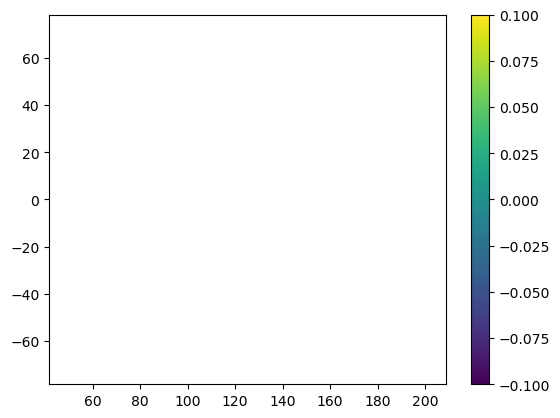

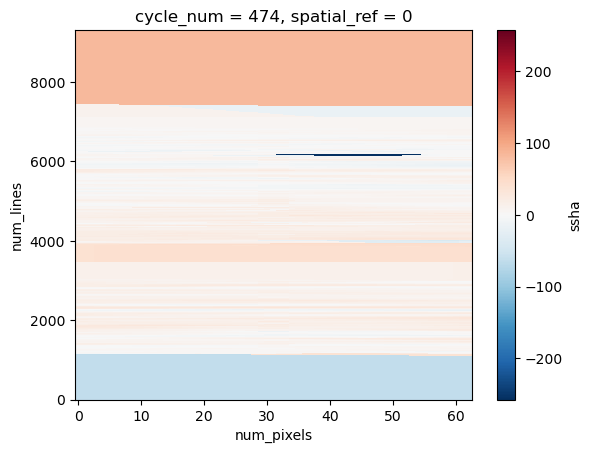

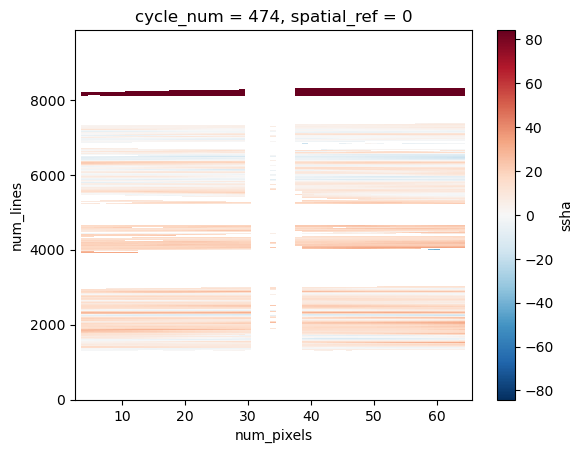

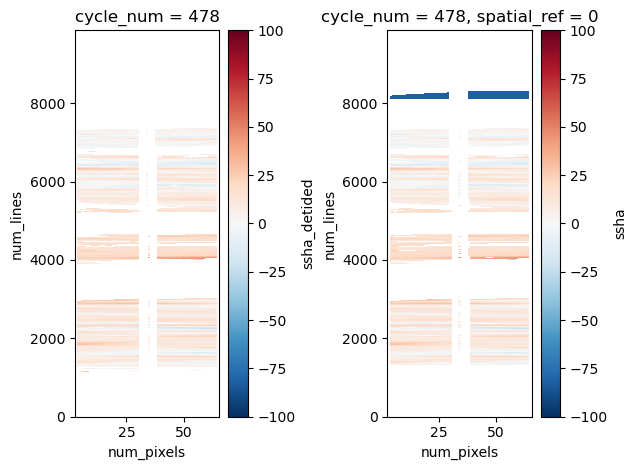

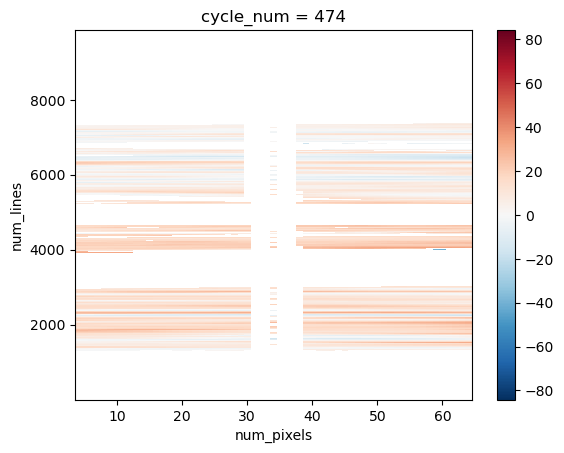

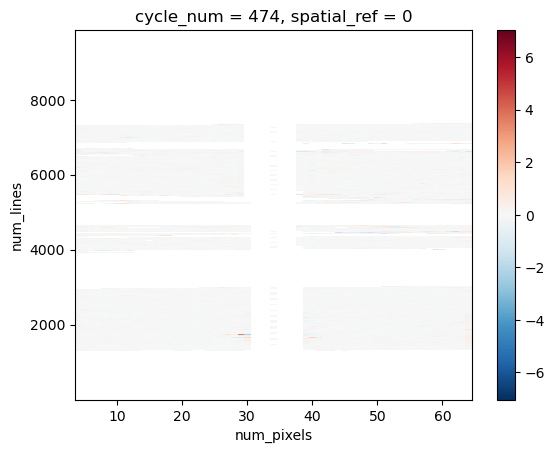

iiiiiiiiiiii
iiPass 021!!
!!!!!!!!!!!!


In [16]:
for ipass in range(21,22):
    ds = xr.open_zarr(op.join(ddir,"SWOT_no_IT/CalVal_pass%03d_v2.0.1.zarr"
                              % ipass))
    ds.coords["num_lines"] = ("num_lines",range(len(ds.num_lines)))
    ds.coords["num_pixels"] = ("num_pixels",range(len(ds.num_pixels)))

    fig, ax = plt.subplots()
    im = ax.pcolor(ds.longitude, ds.latitude,
              ds.ssha_detided.isel(cycle_num=1), 
              rasterized=True
             )
    fig.colorbar(im)
    plt.show()

    inp = 3
    maskn = xr.DataArray(ds.latitude.where(ds.latitude>5.).to_masked_array().mask,
                         dims=ds.latitude.dims,
                         coords=ds.latitude.coords
                        )
    masks = xr.DataArray(ds.latitude.where(ds.latitude<-5.).to_masked_array().mask,
                         dims=ds.latitude.dims,
                         coords=ds.latitude.coords
                        )
    dsns = ds.where(~maskn,drop=True)
    dsns = xr.concat([dsns, ds.where(~masks,drop=True)
                     ], "num_lines"
                    ).sortby("num_lines")

    maskns = xr.DataArray(dsns.ssha_detided.to_masked_array().mask.mean(axis=0), 
                          dims=dsns.ssha_detided.isel(cycle_num=0).dims, 
                          coords=dsns.ssha_detided.isel(cycle_num=0).coords
                         )
    mm = xr.DataArray(maskns.where(maskns<.5
                                  ).to_masked_array().mask,
                      dims=dsns.ssha_detided.isel(cycle_num=0).dims, 
                      coords=dsns.ssha_detided.isel(cycle_num=0).coords
                     ).isel(num_pixels=slice(inp,-inp))

    r_ref = (~mm).sum() / np.prod(mm.shape)

    ic = 0
    for cc in dsns.cycle_num:
        
        ssha = dsns.ssha_detided.sel(cycle_num=cc
                                    ).isel(num_pixels=slice(inp,-inp))
        
        array = ssha.to_masked_array()
        mask = ~array.mask
        ratio = mask.sum() / np.prod(mask.shape)
        if ic == 0:
            R = xr.DataArray(np.array([ratio]), 
                             dims='cycle_num', 
                             coords={'cycle_num':np.array([cc.values,])}
                            )
        else:
            R = xr.concat([R, xr.DataArray(np.array([ratio]), 
                                   dims='cycle_num', 
                                   coords={'cycle_num':np.array([cc.values,])}
                                          )
                          ], 'cycle_num')
        if ratio > .7*r_ref:
            if ic == 0:
                H = ssha
            else:
                if "H" in locals():
                    H = xr.concat([H, ssha], 'cycle_num')
                else:
                    print("Creating H.")
                    H = ssha
            ic += 1
        # else:
            # ssha.plot(rasterized=True)
            # plt.show()
        del ssha, mask, array
    
    H.coords["cycle_num"] = ("cycle_num",
                             R.where(R>0.7*r_ref, drop=True).cycle_num.data
                            )

    dsH = H.to_dataset(name="ssha").swap_dims({'num_pixels':'x', 
                                               'num_lines':'y'}
                                             ).reset_coords(drop=True)
    dsH.coords["y"] = ("y",range(len(dsH.y)))
    dsH.coords["x"] = ("x",range(len(dsH.x)))
    if not dsH.rio.crs:
        dsH = dsH.rio.write_crs("EPSG:4326")
    if dsH.ssha.rio.nodata is None:
        dsH["ssha"] = dsH.ssha.rio.write_nodata(np.nan)
    _H_exterp = dsH.rio.interpolate_na().swap_dims({'x':'num_pixels', 
                                                    'y':'num_lines'}
                                                  ).ssha
    _H_exterp.isel(cycle_num=0).plot(rasterized=True)
    plt.show()

    del H
    dsH.close()

    H_exterp = _H_exterp.where(mm!=1)
    H_exterp.isel(cycle_num=0).plot(rasterized=True)

    fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2)
    fig.set_tight_layout(True)
    dsns.ssha_detided.sel(cycle_num=478
                         ).isel(num_pixels=slice(inp,-inp)
                               ).plot(ax=ax1, rasterized=True, vmax=1e2)
    H_exterp.sel(cycle_num=478).plot(ax=ax2, rasterized=True, vmax=1e2)
    plt.show()

    wet_mask = xr.DataArray(mm.where(mm!=0).to_masked_array().mask.astype(np.float64),
                            dims=mm.dims, coords=mm.coords
                           ).reset_coords(drop=True)
    
    regular_filter = gcm_filters.Filter(
        filter_scale=fscale,
        dx_min=1,
        filter_shape=gcm_filters.FilterShape.GAUSSIAN,
        grid_type=gcm_filters.GridType.REGULAR_WITH_LAND,
        grid_vars={'wet_mask': wet_mask,
        }
    )
    
    _sshm = regular_filter.apply(_H_exterp.chunk({'num_lines':-1,'num_pixels':-1}), 
                             dims=['num_lines','num_pixels']
                            ).reset_coords(drop=True).where(mm!=1).chunk({"cycle_num":1,
                                                             "num_lines":-1,"num_pixels":-1}
                                                           ).isel(num_pixels=slice(1,-1),
                                                                  num_lines=slice(1,-1)
                                                                 )
    if ipass == 21:
        _sshm[dict(num_lines=range(7499,len(_sshm.num_lines)))] = np.nan
        
    _sshm.isel(cycle_num=0).plot()
    plt.show()
    (_H_exterp.isel(num_pixels=slice(1,-1),num_lines=slice(1,-1))
     - _sshm).isel(cycle_num=0).plot()
    plt.show()
    
    dsave = _sshm.to_dataset(name="ssha"
                            ).to_zarr(op.join(ddir,
                          'CalVal/Pass%03d/ssha_rawgrid_%02dpoints.zarr' 
                          % (ipass,int(fscale))
                                             ), mode='w'
                                     )
    print("iiiiiiiiiiii")
    print("iiPass %03d!!" % ipass)
    print("!!!!!!!!!!!!")